# Lab 5
# Classification  

## Import Libraries

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# <span style="color:red;">➡Load The Data:</span> 

In [7]:
df = pd.read_csv('mail_data.csv') # , encoding='latin-1'

In [8]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


#  <span style="color:red;">➡Data Exploration:</span>

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
df.shape

(5572, 2)

# <span style="color:red;">➡Data preprocessing</span>

# Step 1:Missing Values Handling:

In [11]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

# Step 2: Duplicate Handling.

In [12]:
df.duplicated().sum()

np.int64(415)

In [13]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['Category'].value_counts()

Category
ham     4516
spam     641
Name: count, dtype: int64

### so the data is unbalanced


# Feature Extraction

In [16]:
# Map 'ham' to 0 and 'spam' to 1
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})  # == Label Encoder

In [17]:
df

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [18]:
import nltk
nltk.download('stopwords')
# the, a, an, and, or, but, if, while
# in, on, at, to, for, from, of, with, by
# is, am, are, was, were, be, been, being
# i, you, he, she, it, we, they, me, him, her
# this, that, these, those, there, here

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
from nltk.corpus import stopwords
stopwords_set = set(stopwords.words("english"))

In [20]:
from nltk.stem import PorterStemmer
import string

stemmer = PorterStemmer() # Used to reduce words to their root form (stemming)
# playing,played,plays ==> play
# connection,connected,connecting==>connect

corpus = []

In [21]:
for i in range(len(df)):
    # Original text example:
    # "Congratulations!!! You are winning, winner!! Win 1000$ now... Call us!!!"
    
    # Convert text to lowercase
    text = df['Message'].iloc[i].lower()
    # "congratulations!!! you are winning, winner!! win 1000$ now... call us!!!"
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    ## "congratulations you are winning winner win 1000 now call us"
    
    # Tokenization
    text = text.split()
    # ['congratulations', 'you', 'are', 'winning', 'winner', 'win', '1000', 'now', 'call', 'us']
    
    # Remove stop words and apply stemming
    text = [stemmer.stem(word) for word in text if word not in stopwords_set]
    # ['congratul', 'win', 'winner', 'win', '1000', 'call', 'us']
    
     # Join words back into a single string
    text = ' '.join(text)
    # "congratul win winner win 1000 call us"
    corpus.append(text)

In [22]:
# Feature extraction using Bag of Words
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(corpus)

In [23]:
print("Number of words in Bag of Words:", 
      len(vectorizer.get_feature_names_out()))


Number of words in Bag of Words: 8094


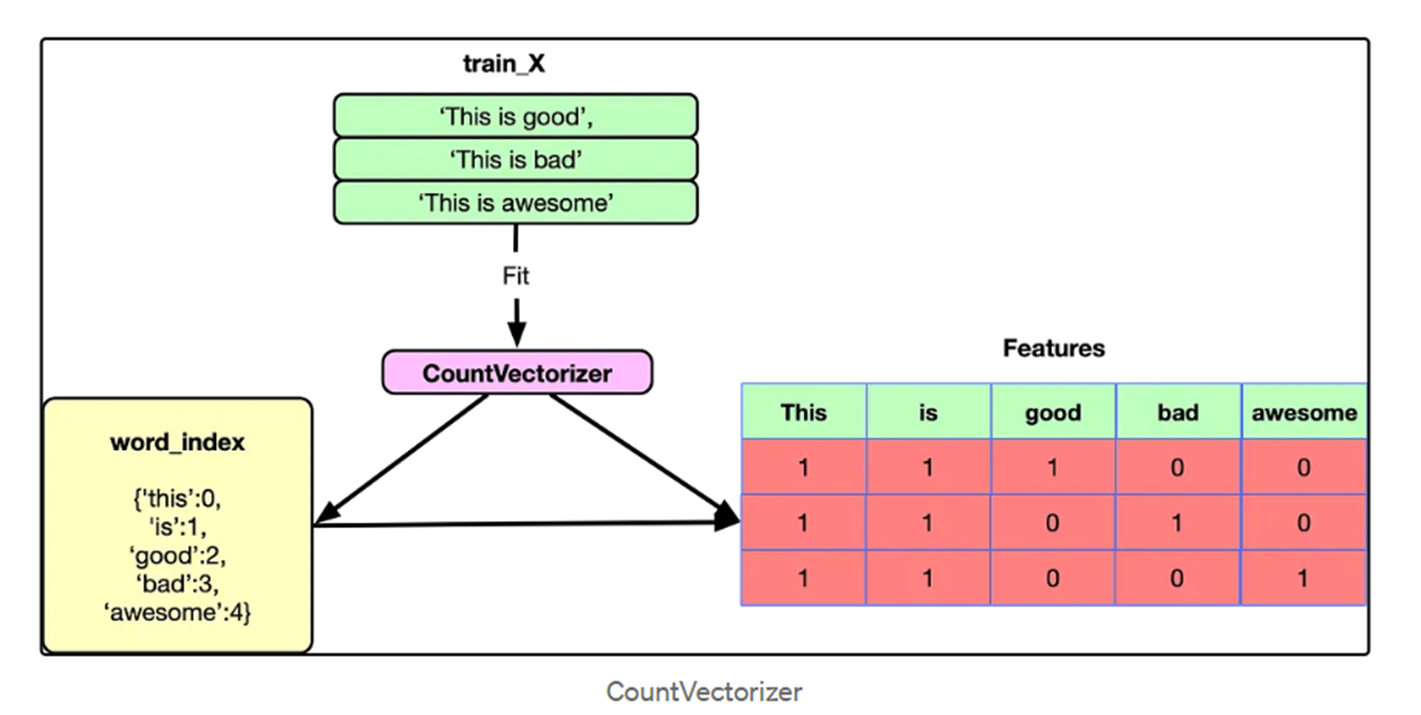

"This is good,very good"

[[1, 1, 2, 1]]


# <span style="color:red;">➡Classification Model</span>

## 1) Define input features (X) and target variable (y)

In [24]:
X = X_counts  # Features
y = df['Category']  # Labels

## 2) Split the data into training and testing sets

In [25]:
# Step 4: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Model

In [26]:
# Step 5: Train the Naive Bayes Classifier
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

# Evaluate the Model

In [27]:
# Step 6: Make predictions
y_pred = model.predict(X_test)

In [28]:
# Step 7: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9718992248062015

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       896
           1       0.85      0.96      0.90       136

    accuracy                           0.97      1032
   macro avg       0.92      0.97      0.94      1032
weighted avg       0.97      0.97      0.97      1032


Confusion Matrix:
 [[872  24]
 [  5 131]]


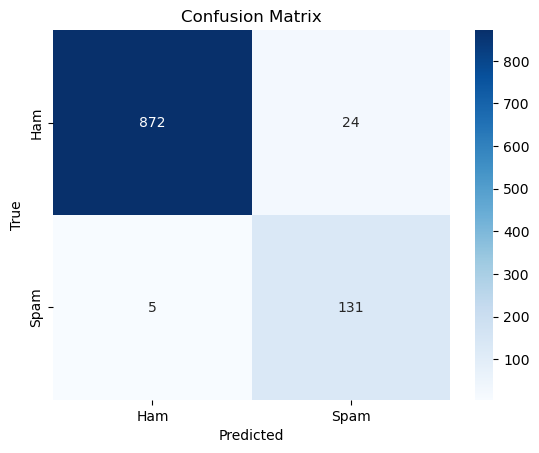

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# Handling Class Imbalance:
# 1. Oversampling – RandomOverSampler

In [30]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

ros = RandomOverSampler(sampling_strategy=0.5,random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print("Before balancing (train):")
print(pd.Series(y_train).value_counts())

print("\nAfter balancing (train):")
print(pd.Series(y_train_res).value_counts())

Before balancing (train):
Category
0    3620
1     505
Name: count, dtype: int64

After balancing (train):
Category
0    3620
1    1810
Name: count, dtype: int64


# Build a model again after use overSampling to handle imbalance in the data

In [31]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model = MultinomialNB(alpha=0.3)
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)  
recall    = recall_score(y_test, y_pred)      
f1        = f1_score(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)



Confusion Matrix:
 [[875  21]
 [  7 129]]
Accuracy: 0.9728682170542635
Precision: 0.86
Recall: 0.9485294117647058
F1-score: 0.9020979020979021


# 2. Undersampling – RandomUnderSampler

In [40]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy=.3,random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("Before balancing (train):")
print(pd.Series(y_train).value_counts())

print("\nAfter balancing (train):")
print(pd.Series(y_train_rus).value_counts())

Before balancing (train):
Category
0    3620
1     505
Name: count, dtype: int64

After balancing (train):
Category
0    1683
1     505
Name: count, dtype: int64


In [41]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model = MultinomialNB()
model.fit(X_train_rus, y_train_rus)

y_pred = model.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)   
recall    = recall_score(y_test, y_pred)      
f1        = f1_score(y_test, y_pred)

# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Confusion Matrix:
 [[871  25]
 [  5 131]]
Accuracy: 0.9709302325581395
Precision: 0.8397435897435898
Recall: 0.9632352941176471
F1-score: 0.8972602739726028
